# LoL 승패 예측·설명 서비스 — 최종 분석 노트북
**4조 · LoL 경기는 언제 승부가 결정되는가?**

이 노트북 하나로 **데이터 적재 → 피처 → 분할 → 베이스라인 → 학습·검증 → 홀드아웃 평가 →
승리요인 해석 → 오류 분석 → 아티팩트 검증**의 전 과정을 재현합니다.
전체 서사는 루트 `README.md`, 단계별 실측 기록은 `docs/experiment_report.md` 참고.

**실행 조건**: `data/high_diamond_ranked_10min.csv` 와 `data/splits/` 가 있어야 하며
(없으면 `src/day1_baseline.py` 먼저), 위에서 아래로 순차 실행합니다. 시드 42 고정.

In [1]:
import json, time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             brier_score_loss, confusion_matrix)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
SEED = 42
# 프로젝트 폴더를 자동으로 찾는다 (data/ 가 있는 곳이 프로젝트 루트)
from pathlib import Path
_r = Path.cwd()
for _ in range(5):
    if (_r / "data").is_dir() and (_r / "predict.py").is_file():
        break
    _r = _r.parent
else:
    raise FileNotFoundError(
        "data/ 와 predict.py 가 있는 프로젝트 폴더를 찾지 못했습니다.")
ROOT = str(_r)
print("프로젝트 폴더:", ROOT)

프로젝트 폴더: C:\AI 캠퍼스 MLOps양성과정\ML\ML실습\4조_LoL 인게임 시점별 경기 데이터 기반 승패 예측 및 핵심 승리요인 분석


## 1. 데이터 적재와 첫 점검
경기 1판 = 1행. 10분 시점 상태 + 최종 승패(`blueWins`). 결측 0 · 중복 0 · 승패 균형을 확인합니다.

In [2]:
# gameId 순으로 정렬 — DB 뷰와 행 순서를 맞춘다.
# StratifiedKFold(shuffle=True) 는 입력 순서에 따라 폴드를 다르게 나누므로,
# 순서를 고정하지 않으면 같은 데이터인데 CV 점수가 미세하게 달라진다.
df = pd.read_csv(f"{ROOT}/data/high_diamond_ranked_10min.csv").sort_values("gameId")
assert df.shape == (9879, 40), df.shape
assert df.isna().sum().sum() == 0 and df["gameId"].duplicated().sum() == 0
print("행 x 열:", df.shape)
print("승패 균형:", df["blueWins"].value_counts(normalize=True).round(4).to_dict())

행 x 열: (9879, 40)
승패 균형: {0: 0.501, 1: 0.499}


## 2. 피처 — 차이 피처 13개 (`diff13`)
원본 38개 중 중복 11개(거울·상수배·선형종속)를 버리고 **블루−레드 차이 13개**로 압축.
"양수 = 블루 우세"로 해석이 통일됩니다. 근거는 `docs/data_analysis.md`.
(정본은 DB 뷰 `v_diff13_*` — 여기서는 같은 계산식의 CSV 폴백)

In [3]:
DIFF13 = ["FirstBlood", "KillsDiff", "GoldDiff", "ExpDiff", "WardsPlacedDiff",
          "WardsDestroyedDiff", "AssistsDiff", "DragonsDiff", "HeraldsDiff",
          "TowersDestroyedDiff", "AvgLevelDiff", "TotalMinionsKilledDiff",
          "TotalJungleMinionsKilledDiff"]
X = pd.DataFrame(index=df.index)
X["FirstBlood"] = df["blueFirstBlood"]
X["KillsDiff"] = df["blueKills"] - df["redKills"]
X["GoldDiff"] = df["blueGoldDiff"]
X["ExpDiff"] = df["blueExperienceDiff"]
for p in ["WardsPlaced", "WardsDestroyed", "Assists", "Dragons", "Heralds",
          "TowersDestroyed", "AvgLevel", "TotalMinionsKilled", "TotalJungleMinionsKilled"]:
    X[f"{p}Diff"] = df[f"blue{p}"] - df[f"red{p}"]
X = X[DIFF13]
y = df["blueWins"]
X.head(3)

,FirstBlood,KillsDiff,GoldDiff,ExpDiff,WardsPlacedDiff,WardsDestroyedDiff,AssistsDiff,DragonsDiff,HeraldsDiff,TowersDestroyedDiff,AvgLevelDiff,TotalMinionsKilledDiff,TotalJungleMinionsKilledDiff
6475,0,4,1864,-797,-2,2,6,-1,0,0,-0.4,-16,-7
7011,1,4,2944,3092,-2,-1,4,1,0,0,1.0,31,20
6904,1,2,339,261,-3,1,0,1,-1,0,0.4,-45,1


## 3. 분할 — 시험지는 봉인, 마지막에 한 번만
Day1에 저장해 둔 분할 인덱스를 **그대로 재사용**합니다(재현성 규약 2).
학습 7,903 / 시험 1,976, 층화 분할, 시드 42.

In [4]:
tr_idx = pd.read_csv(f"{ROOT}/data/splits/train_idx.csv")["idx"].values
te_idx = pd.read_csv(f"{ROOT}/data/splits/test_idx.csv")["idx"].values
assert len(set(tr_idx) & set(te_idx)) == 0
m_tr, m_te = X.index.isin(tr_idx), X.index.isin(te_idx)   # 정렬 순서 유지
X_tr, y_tr = X[m_tr], y[m_tr]
X_te, y_te = X[m_te], y[m_te]
print(f"train {X_tr.shape} / test {X_te.shape} (봉인 — 6장에서 딱 한 번 개봉)")

train (7903, 13) / test (1976, 13) (봉인 — 6장에서 딱 한 번 개봉)


## 4. 베이스라인 — "찍기"보다 나은가
승패가 반반이라 한쪽으로만 찍어도 약 50%. 모든 성능 주장은 이 기준선과의 비교로 시작합니다.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
dummy = cross_validate(DummyClassifier(strategy="most_frequent"), X_tr, y_tr,
                       cv=cv, scoring=["accuracy"])
baseline_acc = dummy["test_accuracy"].mean()
print(f"찍기 기준선(교차검증 정확도): {baseline_acc:.4f}")

찍기 기준선(교차검증 정확도): 0.5009


## 5. 모델 학습과 교차검증
8종 비교(`docs/experiment_report.md` 3장)에서 **로지스틱 회귀**가 정확도 1위 + 과적합 최소 +
해석 가능이라 채택됐습니다. 전처리(StandardScaler)는 Pipeline 안에 넣어
교차검증·저장·서빙에서 같은 변환을 보장합니다.
안정성 기준: 폴드 표준편차 < 0.02, 학습−검증 격차 < 0.03.

In [6]:
pipe = Pipeline([("scaler", StandardScaler()),
                 ("model", LogisticRegression(max_iter=1000, random_state=SEED))])
res = cross_validate(pipe, X_tr, y_tr, cv=cv, scoring=["accuracy", "f1"],
                     return_train_score=True, n_jobs=1)
cv_acc, cv_std = res["test_accuracy"].mean(), res["test_accuracy"].std()
gap = res["train_accuracy"].mean() - cv_acc
print(f"교차검증 정확도 {cv_acc:.4f} ± {cv_std:.4f} | 학습-검증 격차 {gap:+.4f}")
assert cv_std < 0.02 and gap < 0.03, "안정성 기준 위반"
print("안정성 기준 통과 — 이 점수는 운이 아님")

교차검증 정확도 0.7325 ± 0.0075 | 학습-검증 격차 +0.0001


안정성 기준 통과 — 이 점수는 운이 아님


## 6. 홀드아웃 최종 평가 — 봉인 개봉 (1회)
성공 기준: 정확도 ≥ 0.70 (하한), 기준선 대비 개선 폭 병기.
임계값은 0.5 — 비용이 대칭이라 조정 불필요함을 사전 확인했습니다(실험보고 7단계).

In [7]:
pipe.fit(X_tr, y_tr)
proba = pipe.predict_proba(X_te)[:, 1]
pred = (proba >= 0.5).astype(int)
acc = accuracy_score(y_te, pred)
print(f"홀드아웃 정확도 {acc:.4f}  (기준선 {baseline_acc:.4f} 대비 {acc-baseline_acc:+.4f})")
print(f"F1 {f1_score(y_te, pred):.4f} | AUC {roc_auc_score(y_te, proba):.4f} | "
      f"Brier {brier_score_loss(y_te, proba):.4f}")
cm = confusion_matrix(y_te, pred)
print(f"혼동행렬: TN {cm[0,0]}  FP {cm[0,1]} / FN {cm[1,0]}  TP {cm[1,1]}")
assert acc >= 0.70, "성공 기준(SC-1) 미달"
print("SC-1 통과")

홀드아웃 정확도 0.7394  (기준선 0.5009 대비 +0.2384)
F1 0.7352 | AUC 0.8150 | Brier 0.1756
혼동행렬: TN 746  FP 244 / FN 271  TP 715
SC-1 통과


## 7. 승리요인 — 두 방법의 교차 검증
**표준화 계수**(방향·크기)와 **permutation importance**(시험셋에서 섞었을 때의 손해)를
대조합니다. 유의미한 요인은 3개뿐이고 두 방법의 순위가 완전히 일치합니다:
**골드 차이 > 경험치 차이 > 드래곤 차이**. 킬 차이는 골드를 통제하면 계수가 음수 —
킬은 돈을 버는 수단일 뿐이라는 뜻입니다("킬 말고 골드", `docs/활용가이드.md`).

In [8]:
coefs = pd.Series(pipe.named_steps["model"].coef_[0], index=DIFF13)
perm = permutation_importance(pipe, X_te, y_te, n_repeats=10,
                              random_state=SEED, scoring="accuracy", n_jobs=1)
rank = pd.DataFrame({"표준화계수": coefs.round(3),
                     "permutation": pd.Series(perm.importances_mean, index=DIFF13).round(4)})
rank.sort_values("permutation", ascending=False)

,표준화계수,permutation
GoldDiff,1.231,0.1863
ExpDiff,0.461,0.0312
DragonsDiff,0.267,0.0127
TotalMinionsKilledDiff,-0.157,0.0036
FirstBlood,0.035,0.0031
TowersDestroyedDiff,-0.064,0.0022
HeraldsDiff,0.050,0.0021
WardsPlacedDiff,-0.016,0.0013
KillsDiff,-0.107,0.0012
AssistsDiff,-0.079,0.0009


## 8. 오류 분석 — "이런 경기에서 틀린다"
정확도를 골드차 구간별로 나누면, 73%라는 숫자의 정체가 드러납니다:
**접전 구간은 10분 정보 자체가 승패를 못 가릅니다.**

,경기수,정확도,비중_%
구간,,,
접전(<1k),680,0.6147,34.4
우세(1k~2.5k),721,0.7406,36.5
크게 우세(2.5k~4.2k),404,0.8589,20.4
사실상 결정(4.2k+),171,0.9474,8.7


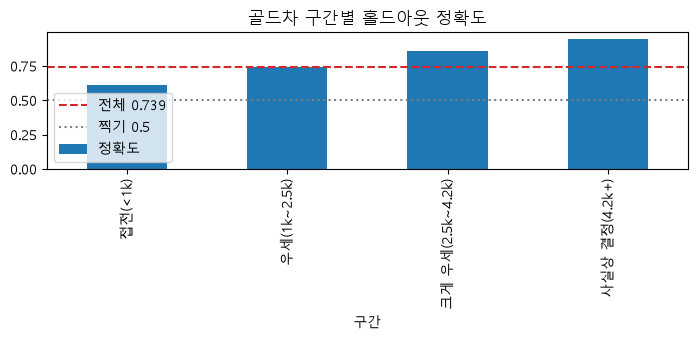

In [9]:
err = pd.DataFrame({"abs_gold": X_te["GoldDiff"].abs().values,
                    "correct": (pred == y_te.values).astype(int)})
bins = [0, 1000, 2500, 4200, np.inf]
labels = ["접전(<1k)", "우세(1k~2.5k)", "크게 우세(2.5k~4.2k)", "사실상 결정(4.2k+)"]
err["구간"] = pd.cut(err["abs_gold"], bins=bins, labels=labels, right=False)
ea = err.groupby("구간", observed=True).agg(경기수=("correct", "size"),
                                            정확도=("correct", "mean")).round(4)
ea["비중_%"] = (ea["경기수"] / ea["경기수"].sum() * 100).round(1)
fig, ax = plt.subplots(figsize=(7, 3.5))
ea["정확도"].plot.bar(ax=ax, color="tab:blue")
ax.axhline(acc, color="tab:red", ls="--", label=f"전체 {acc:.3f}")
ax.axhline(0.5, color="gray", ls=":", label="찍기 0.5")
ax.set_title("골드차 구간별 홀드아웃 정확도"); ax.legend(); plt.tight_layout()
ea

## 9. 아티팩트 검증 — 남이 쓸 수 있는 상태인가
`src/finalize_model.py` 가 저장한 `artifacts/model.joblib` 을 복원해,
이 노트북에서 학습한 모델과 **예측이 완전히 일치**하는지 확인합니다
(같은 데이터·같은 시드·같은 파이프라인이므로 일치해야 정상).
서비스에서는 `predict.py` 가 이 아티팩트의 유일한 소비자입니다.

In [10]:
restored = joblib.load(f"{ROOT}/artifacts/model.joblib")
assert (restored.predict(X_te) == pred).all(), "저장된 아티팩트와 예측 불일치"
schema = json.load(open(f"{ROOT}/artifacts/schema.json", encoding="utf-8"))
print("아티팩트 예측 일치 assert 통과")
print("schema.json 기록 성능:", schema["metrics_holdout"])
assert schema["metrics_holdout"]["accuracy"] == round(acc, 4), "schema 기록과 재현 결과 불일치"
print("schema 기록 성능 == 이 노트북 재현 성능 — 재현성 확인 완료")

아티팩트 예측 일치 assert 통과
schema.json 기록 성능: {'accuracy': 0.7394, 'f1': 0.7352, 'auc': 0.815, 'brier': 0.1756, 'baseline_accuracy': 0.501}
schema 기록 성능 == 이 노트북 재현 성능 — 재현성 확인 완료


## 결론

- 10분 정보만으로 **정확도 0.71**, 찍기 대비 **+21%p**. 그러나 이 숫자는 평균일 뿐 —
  골드차 4,200+ 경기(9%)는 95%를 맞히고, 접전(32%)은 찍기 수준입니다.
- **승부를 가르는 것은 골드 > 경험치 > 드래곤.** 킬 수 자체는 기여하지 않습니다.
- 따라서 "경기는 언제 결정되는가?"의 답: **경기마다 다르고, 그 경계는 골드차다.**

**한계**: 수집 시점 패치·다이아 랭크에 한정, 접전 구간은 원리적 한계.
후속 과제(10 vs 15분 시점 비교 등)와 사용 금지 상황은 `model_card.md` 참고.